### Import the necessary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the training data from train.csv file

In [7]:
train_labels = pd.read_csv('train_labels.csv')
train_labels.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


### Print the shape of the train dataset

In [6]:
train_labels.shape

(173, 8)

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [8]:
IMAGE_SIZE=128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

### Define a custom loss function IoU which calculates Intersection Over Union

In [ ]:
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

### Pick a test image from the given data

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

### Predict the coordinates of the bounding box for the given test image

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

In [ ]:
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()

## Time Series Analysis using LSTM

### Download Data
Link: https://datamarket.com/data/set/2324/daily-minimum-temperatures-in-melbourne-australia-1981-1990#!ds=2324&display=line

#### Description
Daily minimum temperatures in Melbourne, Australia, 1981-1990

Units: Degrees Celcius

#### Steps before loading
- Rename the column name with temperature values to "Temperature"
- In the last, there is one extra row in the data, remove it by opening the file and save it again.
- There are some values in Temperature column which have a "?" before them, they will give error, remove "?" before them and save the file
- If you don't want to do these steps, just load the data file given by Great Learning.

### Import required libraries

In [184]:
temperature_data = pd.read_csv('daily-minimum-temperatures-in-me.csv')

In [185]:
temperature_data.head()

,Date,Temperature
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [186]:
temperature_data.dtypes

Date            object
Temperature    float64
dtype: object

In [187]:
temperature_data['Date'] = pd.to_datetime(temperature_data['Date'])

In [188]:
temperature_data.dtypes

Date           datetime64[ns]
Temperature           float64
dtype: object

In [189]:
temperature_data.shape

(3650, 2)

#### Mount google drive

### Load the  data file

### Plot the data

In [190]:
temperature_data.plot(figsize=(15,5))

ValueError: view limit minimum -36341.6 is less than 1 and is an invalid Matplotlib date value. This often happens if you pass a non-datetime value to an axis that has datetime units

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x1138e8ae8> (for post_execute):


ValueError: view limit minimum -36341.6 is less than 1 and is an invalid Matplotlib date value. This often happens if you pass a non-datetime value to an axis that has datetime units

ValueError: view limit minimum -36341.6 is less than 1 and is an invalid Matplotlib date value. This often happens if you pass a non-datetime value to an axis that has datetime units

### Check for null values and treat them

In [191]:
temperature_data.isna().sum()

Date           0
Temperature    0
dtype: int64

#### Drop null values (if any)

In [192]:
temperature_data.isnull().sum()

Date           0
Temperature    0
dtype: int64

### Get the representation of the distribution of data in the form of histogram

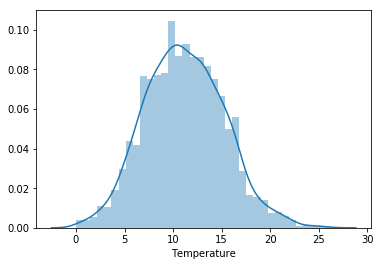

In [193]:
sns.distplot(temperature_data['Temperature'])

### Check the maximum and minimum values

In [194]:
temperature_data['Temperature'].max() , temperature_data['Temperature'].min()

(26.3, 0.0)

### Normalize the data

In [195]:
temperature_mean = temperature_data['Temperature'].mean()
temperature_std = np.sqrt(temperature_data['Temperature'].var())

In [196]:
temperature_data['Temperature'] = temperature_data['Temperature'].apply(lambda x:(x-temperature_mean)/ temperature_std)    

### Check the maximum and minimum values of scaled data

In [197]:
temperature_data['Temperature'].max() , temperature_data['Temperature'].min()

(3.7138635335765087, -2.745137809010065)

### Split data into Training and Testing set 
<u>Note</u> The train and test data has to be sequential. Keep the first 70% of data in training and the bottom 30% in test data 

In [44]:
temperature_data.set_index('Temperature') #set temp as index
split_date = len(temperature_data['Temperature'])*0.7 #70% split row number
train = temperature_data.loc[:split_date, ]
test = temperature_data.loc[split_date:, ]

In [45]:
train.shape, test.shape

((2556, 2), (1095, 2))

In [46]:
train.head()

,Date,Temperature
0,1981-01-01,2.338563
1,1981-01-02,1.650913
2,1981-01-03,1.871943
3,1981-01-04,0.840467
4,1981-01-05,1.135175


In [198]:
# split into train and test sets
train_size = int(len(temperature_data) * 0.7)
test_size = len(temperature_data) - train_size
train, test = temperature_data[0:train_size], temperature_data[train_size+1:len(temperature_data)]
print(len(train), len(test))

2555 1094


## Create the sequential data
Map the temperature at a particular time t to the temperature at time t+n, where n is any number you define.

For example: to map temperatures of consecutive days, use t+1, i.e. loop_back = 1

#### Define your function to create dataset

In [199]:
for s in range(1, 2):
    train['shift_{}'.format(s)] = train['Temperature'].shift(s)
    test['shift_{}'.format(s)] = test['Temperature'].shift(s)

/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  
/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [200]:
train.head()

,Date,Temperature,shift_1
0,1981-01-01,2.338563,NaN
1,1981-01-02,1.650913,2.338563
2,1981-01-03,1.871943,1.650913
3,1981-01-04,0.840467,1.871943
4,1981-01-05,1.135175,0.840467


### Use function to get training and test set

In [201]:
X_train = train.dropna().drop('Temperature', axis=1)
y_train = train.dropna()[['Temperature']]

X_test = test.dropna().drop('Temperature', axis=1)
y_test = test.dropna()[['Temperature']]

In [202]:
X_train.shape, X_test.shape,y_train.shape, y_test.shape

((2554, 2), (1093, 2), (2554, 1), (1093, 1))

### Transform the prepared train and test input data into the expected structure using numpy.reshape()

In [203]:
X_train = X_train.values
X_test= X_test.values

y_train = y_train.values
y_test = y_test.values

In [204]:
X_train_t = X_train.reshape(X_train.shape[0], 1, 2)
X_test_t = X_test.reshape(X_test.shape[0], 1, 2)

In [205]:
X_train_t.shape

(2554, 1, 2)

### Define sequntial model, add LSTM layer and compile the model

In [206]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import keras.backend as K
from keras.callbacks import EarlyStopping


K.clear_session()
model = Sequential()

model.add(LSTM(6, input_shape=(1, 2)))

model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

In [207]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 6)                 216       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 7         
Total params: 223
Trainable params: 223
Non-trainable params: 0
_________________________________________________________________


### Train the model for 100 epochs with batch size = 1

In [208]:
early_stop = EarlyStopping(monitor='loss', patience=1, verbose=1)

In [209]:
X_train_t[0]

array([[Timestamp('1981-01-02 00:00:00'), 2.3385628674744243]],
      dtype=object)

In [210]:
model.fit(X_train_t, y_train, epochs=100,
          batch_size=1, verbose=1,
          callbacks=[early_stop])

Epoch 1/100


TypeError: float() argument must be a string or a number, not 'Timestamp'

### Make Predictions and Evaluate your model

In [ ]:
import math
from sklearn.metrics import mean_squared_error

trainPredict = model.predict(X_train, batch_size=batch_size)

model.reset_states()

testPredict = model.predict(X_test, batch_size=batch_size)

# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))